In [34]:
import os
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from core.brailleimages import read_cleaned, HOGTransformer, GaussianTransformer, SatoTransformer

raw_folderpath = "../data/raw/braille-character-dataset/Braille Dataset/Braille Dataset"
processed_folderpath = "../data/processed/braille-character-dataset"

df = read_cleaned(os.path.join(processed_folderpath, 'braille.csv'))

In [2]:
%load_ext autoreload

%autoreload 2

In [ ]:
# parameter search
features = df.iloc[:, :-3]
target = df.loc[:, 'letter']

hogify = HOGTransformer(orientations=7, pixels_per_cell=(9, 9))
pipe_hog_std = Pipeline([('hog', hogify), ('std', StandardScaler())])
features_hog_std = pipe_hog_std.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(features_hog_std, target, stratify=target, test_size=.2, random_state=1)

forest = RandomForestClassifier(
    max_features='log2', 
    random_state=42)

search_space = {
    'n_estimators': [100, 300, 800, 1000],
    'max_depth': [19, 20, 21, 23],
}
param_search = GridSearchCV(estimator=forest, param_grid=search_space, scoring='accuracy', cv=5, verbose=4)
param_search.fit(X_train, y_train)
print(param_search.best_score_)
print(param_search.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ....max_depth=19, n_estimators=100;, score=0.812 total time=   0.6s
[CV 2/5] END ....max_depth=19, n_estimators=100;, score=0.832 total time=   0.7s
[CV 3/5] END ....max_depth=19, n_estimators=100;, score=0.872 total time=   0.7s
[CV 4/5] END ....max_depth=19, n_estimators=100;, score=0.815 total time=   0.6s
[CV 5/5] END ....max_depth=19, n_estimators=100;, score=0.847 total time=   0.7s
[CV 1/5] END ....max_depth=19, n_estimators=300;, score=0.828 total time=   1.8s
[CV 2/5] END ....max_depth=19, n_estimators=300;, score=0.828 total time=   2.0s
[CV 3/5] END ....max_depth=19, n_estimators=300;, score=0.888 total time=   1.9s
[CV 4/5] END ....max_depth=19, n_estimators=300;, score=0.839 total time=   1.9s
[CV 5/5] END ....max_depth=19, n_estimators=300;, score=0.859 total time=   1.9s
[CV 1/5] END ....max_depth=19, n_estimators=800;, score=0.832 total time=   4.8s
[CV 2/5] END ....max_depth=19, n_estimators=800;

In [42]:
features = df.iloc[:, :-3]
target = df.loc[:, 'letter']

X_train, X_test, y_train, y_test = train_test_split(features, target, stratify=target, test_size=.2, random_state=1)

forest = RandomForestClassifier( 
    n_estimators=500,
    max_depth=23,
    max_features='log2', 
    random_state=28)

pipe = Pipeline([
    ('gauss', GaussianTransformer(sigma=2.9)), 
    ('sato', SatoTransformer()),
    ('hog', HOGTransformer(orientations=7, pixels_per_cell=(9, 9))), 
    ('std', StandardScaler()), 
    ('rf', forest)])

pipe.fit(X_train, y_train)
preds_train = pipe.predict(X_train)
preds_test = pipe.predict(X_test)
print(accuracy_score(y_train, preds_train))
print(accuracy_score(y_test, preds_test))

1.0
0.9615384615384616


In [40]:
# Does recognition work better on non-dimmed images?

mask_light = df.loc[:, 'augmentation'].ne('dim')
df_light = df.loc[mask_light, :]
target = df_light.loc[:, 'letter']

_, X_test_light, _, y_test_light = train_test_split(df_light.iloc[:, :-3], target, stratify=target, test_size=.2, random_state=1)
preds_test_light = pipe.predict(X_test_light)
print(accuracy_score(y_test_light, preds_test_light)) # yes

0.9903846153846154


              precision    recall  f1-score   support

           a       1.00      0.92      0.96        12
           b       1.00      1.00      1.00        12
           c       0.92      1.00      0.96        12
           d       1.00      1.00      1.00        12
           e       0.91      0.83      0.87        12
           f       1.00      0.92      0.96        12
           g       1.00      1.00      1.00        12
           h       1.00      0.83      0.91        12
           i       0.86      1.00      0.92        12
           j       0.92      1.00      0.96        12
           k       0.92      1.00      0.96        12
           l       1.00      1.00      1.00        12
           m       0.91      0.83      0.87        12
           n       0.92      1.00      0.96        12
           o       0.92      1.00      0.96        12
           p       1.00      1.00      1.00        12
           q       0.86      1.00      0.92        12
           r       1.00    

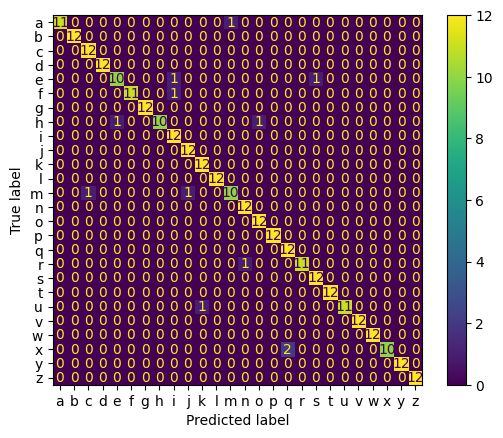

In [44]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(f"{classification_report(y_test, preds_test)}\n")

cm = ConfusionMatrixDisplay.from_predictions(y_test, preds_test)
cm.figure_.savefig("../docs/confusion_matrix_rf.png")